In [1]:
""" 
PROGRAM :  diagnostics_basics.ipynb 

reads in intpp assimilation runs, historical simulations 
and raw forecasts under CMIP6 emissions 
to produce some basic diagnostics

STATUS  : Complete 
COMMENTS: (1) No adjusted forecast shown her
"""

' \nPROGRAM :  diagnostics_basics.ipynb \n\nreads in intpp assimilation runs, historical simulations \nand raw forecasts under CMIP6 emissions \nto produce some basic diagnostics\n\nSTATUS  : Complete \nCOMMENTS: (1) No adjusted forecast shown her\n'

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(1, '/home/rpg002/BGC_skill')

from fnmatch import fnmatch
import pandas as pd
import configs
from prepare import (prepare_data_for_analysis, 
                     write_model_obs_data_to_dataframe,
                     infer_carbonate_chemistry, 
                     get_common_locations, 
                     extract_regional_mask,
                     experiment_finder)

from modules.plotting.scatter_diagrams import *



In [56]:
units = configs.units
boundaries_dict = configs.boundaries_dict
model_lev_bounds = configs.model_lev_bounds
model_levels = configs.model_levels
unit_change_dics = configs.unit_change_dics
varx = configs.varx

### Configs

In [ ]:
data_directory = '/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data'


assimilation_BGC_run_id = None
CanOE_assimilation_BGC_run_id = 1

var_list = [ 'talk', 'so'] #,'talk','dissic', 'no3',  'silicate', 'po4']
experiment_list = ['observation','assimilation', 'historical']
model_list = ['CanESM5', 'CanESM5-CanOE']
obs_source = 'GLODAP'  ## this could be a dictionary for each variable as they might have different sources.

biomes_to_show = ['NEP']
carbonate_var_list = ['saturation_aragonite_out', 'pH']

calculate_talk_dissic_diff = True
calculate_assimilation_historical_diff = False
get_climatolgy = False

### Data Loading

In [5]:
data_em_dicts, obs_mask, model_mask , mask_ocean_surface = prepare_data_for_analysis(var_list,
                            experiment_list,
                            model_list,
                            obs_source,
                            data_directory ,
                            unit_change_dics,
                            assimilation_BGC_run_id = None,
                            CanOE_assimilation_BGC_run_id = 1,
                            nldyr = 1, 
                            varx_dicts = varx,
                            verbose = True)


observation directories: 

/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/talk/observation/GLODAP
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/so/observation/GLODAP

model directories: 

talk assimilation: 
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/talk/assimilation/CanESM5
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/talk/assimilation/CanESM5-CanOE_1
talk historical: 
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/talk/historical/CanESM5
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/talk/historical/CanESM5-CanOE
so assimilation: 
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/so/assimilation/CanESM5
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/so/assimilation/CanESM5-CanOE_1
so historical: 
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/so/historical/CanESM5
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/so/historical/CanESM5-CanOE
loading CanESM5 talk assimilation...
done.
loading C

In [6]:
regional_biomes = {}
for region in biomes_to_show:
    boundaries = boundaries_dict[region]
    regional_biomes[region] = extract_regional_mask(mask_ocean_surface,  **boundaries)


In [7]:
idisplay=False

if idisplay:

    ax = plt.subplot(1,1,1)
    ax.pcolormesh(mask_ocean_surface.lon, mask_ocean_surface.lat, mask_ocean_surface.where(mask_ocean_surface ==0).values, vmin = 0, vmax =1)
    for region in regional_biomes:
        if region not in ['NH', 'SH']:
            mesh = ax.pcolormesh(regional_biomes[region].lon, regional_biomes[region].lat, regional_biomes[region].where(regional_biomes[region] == 1).values, vmin = 0, vmax =1)

    plt.scatter(-50.5, 43.5, color='red', s=10, label='My Point', zorder=10)

In [8]:
idisplay=False

if idisplay:
    print('checking loaded data')
    for var in data_em_dicts:
        for exp in data_em_dicts[var]:
            print(f'{var} {exp}')
            display(data_em_dicts[var][exp].data)




### Data Prep

In [9]:
climatology = True


In [ ]:
dataframe_dict_biome, dict_clim_data = write_model_obs_data_to_dataframe(data_em_dicts,
                                                      regional_biomes,
                                                      min_count = 1,
                                                      model_lev_bounds = model_lev_bounds,
                                                      model_levels = model_levels,
                                                      get_climatolgy = get_climatolgy)

NEP:
        talk 
        so 


In [ ]:
if carbonate_var_list is not None:
    for biome in dataframe_dict_biome:
        dataframe_dict_biome[biome] = infer_carbonate_chemistry(dataframe_dict_biome[biome], carbonate_var_list)

In [17]:
if calculate_talk_dissic_diff:
    for biome in dataframe_dict_biome:

        if all(['talk' in dataframe_dict_biome[biome], 'dissic' in dataframe_dict_biome[biome]]):        
    

            ds_dicts, location_ref = get_common_locations(dataframe_dict_biome[biome]['dissic'], dataframe_dict_biome[biome]['talk'])

            dataframe_dict_biome[biome]['talk - dissic'] = location_ref
            for key in [key for key in list(location_ref.columns) if key not in ['year', 'time', 'lat', 'lon', 'lev', 'count', 'var']]:
                    dataframe_dict_biome[biome]['talk - dissic'][key] = location_ref[key] - ds_dicts[key]
        else:
            print('both talk and dissic must exist for talk-dissic calucaltion.')


    if all(['talk' in data_em_dicts, 'dissic' in data_em_dicts]):
            
        data_em_dicts['talk - dissic'] = {}
        for ds in data_em_dicts['talk']:
            if 'obs' not in ds:
                data_em_dicts['talk - dissic'][ds] = data_em_dicts['talk'][ds]
                data_em_dicts['talk - dissic'][ds].data = data_em_dicts['talk'][ds].data - data_em_dicts['dissic'][ds].data

    else:
        print('both talk and dissic must exist for talk-dissic calucaltion.')

both talk and dissic must exist for talk-dissic calucaltion.
both talk and dissic must exist for talk-dissic calucaltion.


In [75]:

if calculate_assimilation_historical_diff:
    for biome in dataframe_dict_biome:
        for var in dataframe_dict_biome[biome]:
                
            model_runs  = [i for i in list(dataframe_dict_biome[biome][var].columns) if any(['CanOE' in i, 'CMOC' in i])]
            for model in model_list:
                ds1 = ds2 = None
                for key in model_runs:
                    if fnmatch(key, f"{model}*assimilation*"):
                        ds1 = dataframe_dict_biome[biome][var][key]  
                    if fnmatch(key, f"{model}*historical*") :
                        ds2 = dataframe_dict_biome[biome][var][key] 
                if any([ds1 is None, ds2 is None]):
                    print(f'both assimilation and historical data do not exist for {var} {model}')
                    continue
                else:    
                    if 'CanOE' not in model:
                        model = f'{model}-CMOC'
                    dataframe_dict_biome[biome][var][f'{model} assimilation - historical'] = ds1 - ds2


In [55]:
colors_dict = {}
shapes_dict = {} 
alphas_dict = {}

data = list(data_em_dicts.values())[0]
for exp in data:
    colors_dict[exp] = data[exp].color
    shapes_dict[exp] = data[exp].marker
    alphas_dict[exp] = data[exp].alpha

## plots

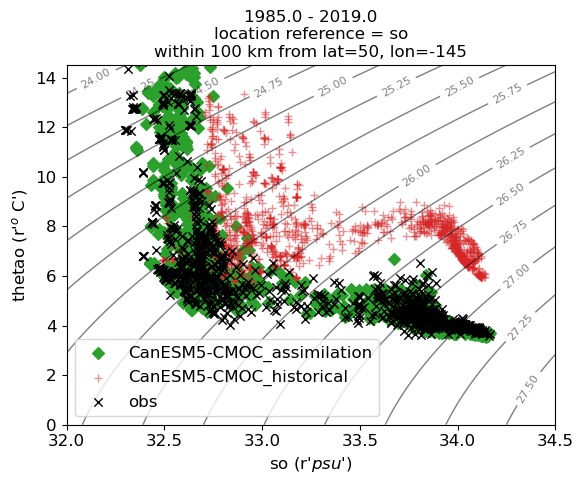

In [51]:
vary = 'thetao'
varx = 'so'
location_ref_var= 'so'

models = ['CanESM5 assimilation' , 'CanESM5 historical', 'obs']
biome_tp = 'NEP'

plot_lim_y = [0,14.5]
plot_lim_x = [32,34.5]
figsize = (6,5)

depth = None 
dataframe = dataframe_dict_biome[biome_tp]
ds_list = experiment_finder(dataframe[vary], model_experiment)

scatter_comparison_singlepanel( dataframe, 
                                var_y = vary, 
                                var_x= varx,
                                ds_list=ds_list, 
                                units=units,
                                location_ref_var = location_ref_var,
                                figsize = figsize, 
                                density_contour=True,
                                plot_lim_y = plot_lim_y, 
                                plot_lim_x = plot_lim_x, 
                                lat = 50,
                                lon  = -145,
                                max_dist_km =100,
                                shapes_dict = shapes_dict,
                                colors_dict=colors_dict,
                                alphas_dict = alphas_dict,
                                calculate_r2=False,
                                calculate_rmse=False,
                                vmin = 0, 
                                vmax = 400)

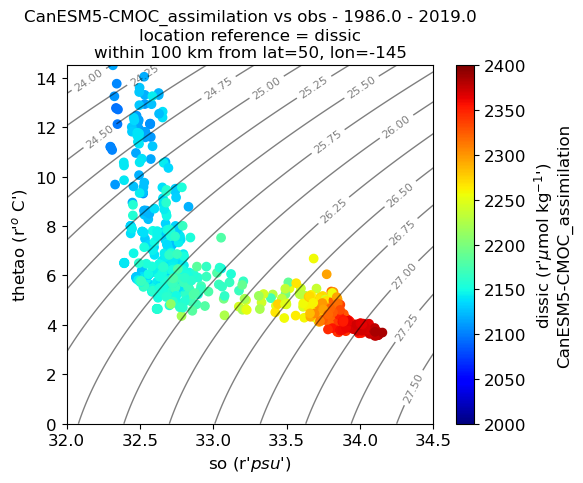

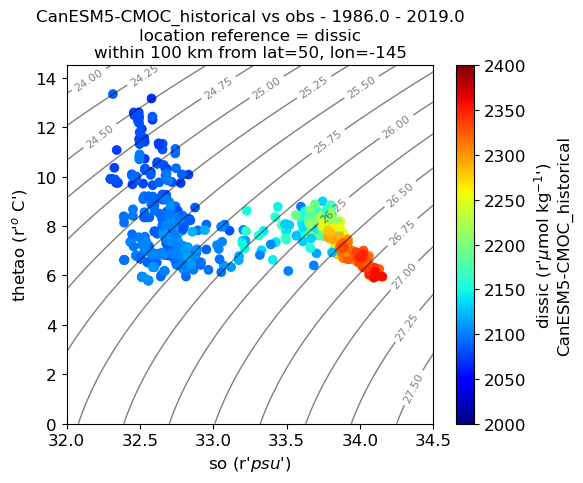

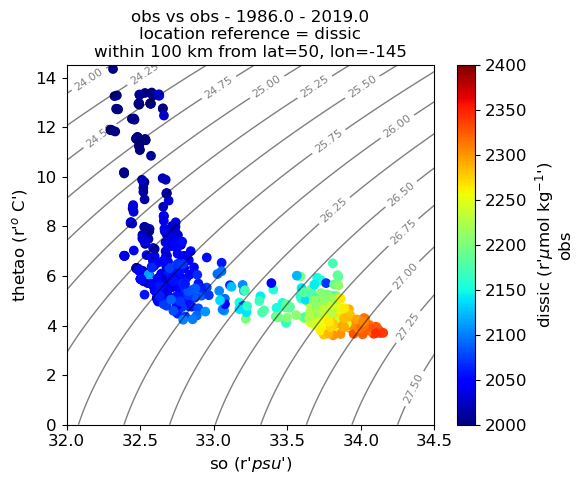

In [ ]:
vary = 'thetao'
varx = 'so'
location_ref_var= 'dissic'
color_bar_var = 'dissic'

model_experiment = ['CanESM5 assimilation' , 'CanESM5 historical', 'obs']
biome_tp = 'NEP'

plot_lim_y = [0,14.5]
plot_lim_x = [32,34.5]
figsize = (6,5)

depth = None 
dataframe = dataframe_dict_biome[biome_tp]
ds_list = experiment_finder(dataframe[vary], model_experiment)

scatter_comparison( dataframe, 
                    var_y = vary, 
                    var_x = varx,
                    ds_list_var_y=ds_list, 
                    units=units,
                    location_ref_var = location_ref_var,
                    figsize = figsize, 
                    plot_lim_y = plot_lim_y, 
                    plot_lim_x = plot_lim_x, 
                    lat = 50,
                    lon  = -145,
                    max_dist_km =100,
                    calculate_r2=False,
                    calculate_rmse=False,
                    density_contour=True,
                    ds_list_color_bar = ds_list,
                    color_bar_var = color_bar_var,
                    cmap = 'jet',
                    vmin = 2000, 
                    vmax = 2400)

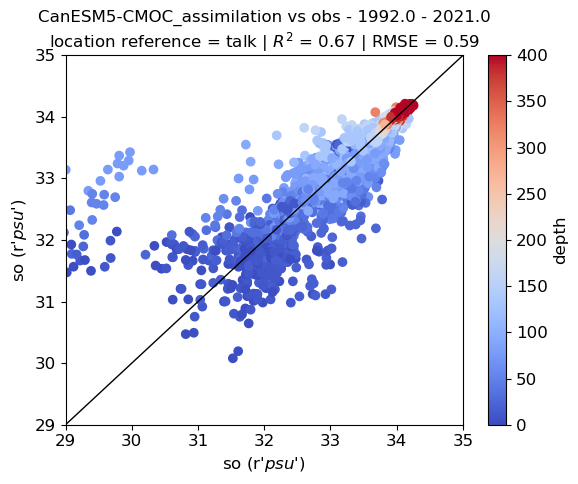

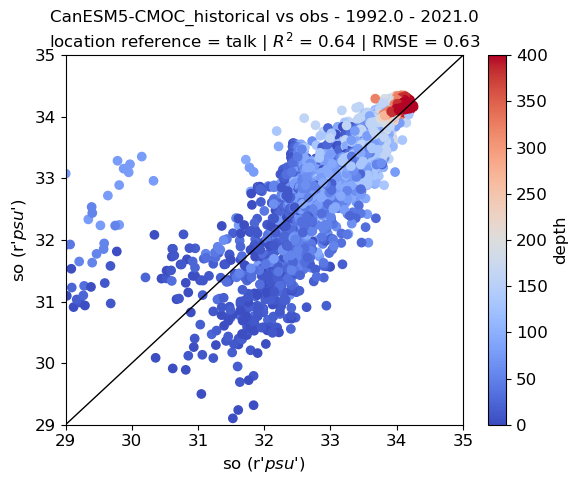

In [ ]:
vary = 'so'

model_experiment = ['CanESM5 assimilation' , 'CanESM5 historical']
biome_tp = 'NEP'
location_ref_var= 'talk'

plot_lim_y = [29,35]
plot_lim_x = [29,35]
figsize = (6,5)

depth = None 
dataframe = dataframe_dict_biome[biome_tp]
ds_list_var_y = experiment_finder(dataframe[vary], model_experiment)
ds_list_var_x = ['obs']

scatter_comparison( dataframe, 
                    var_y = vary, 
                    ds_list_var_y=ds_list_var_y, 
                    ds_list_var_x = ds_list_var_x,
                    location_ref_var=location_ref_var,
                    units=units,
                    figsize = figsize, 
                    plot_lim_y = plot_lim_y, 
                    plot_lim_x = plot_lim_x,
                    calculate_r2=True,
                    calculate_rmse=True,
                    vmin = 0, 
                    vmax = 400)

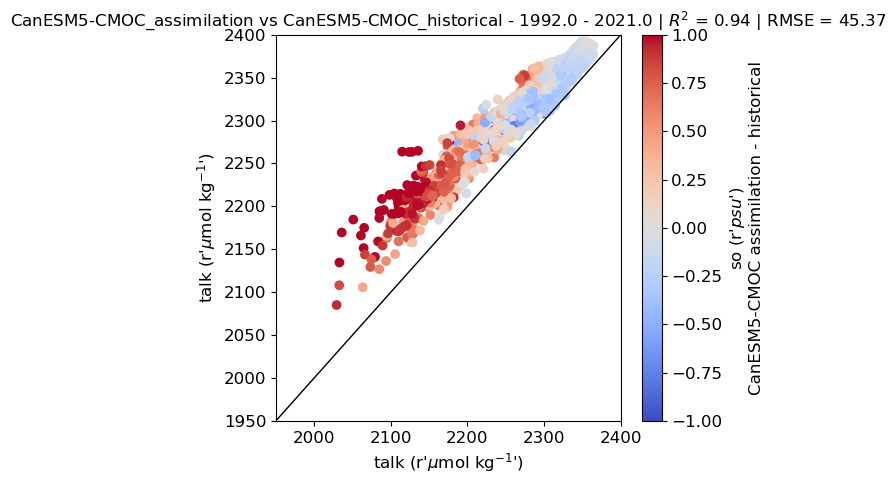

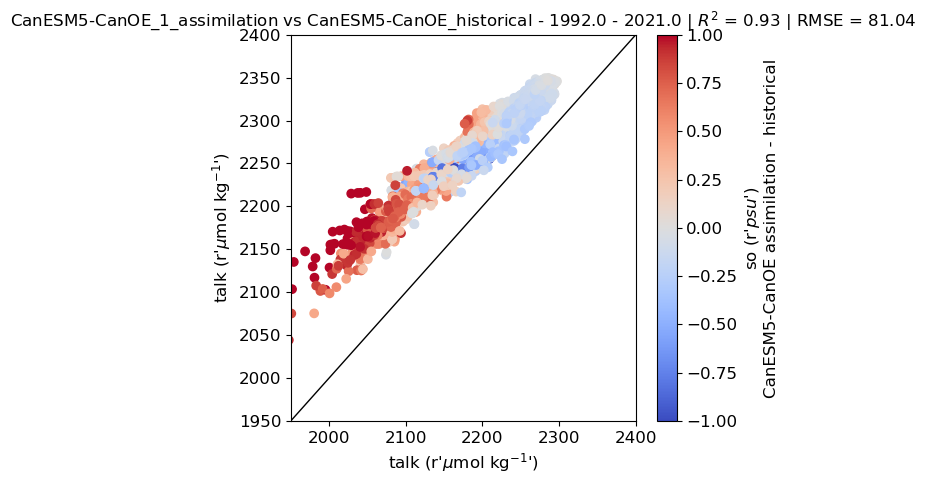

In [80]:
vary = 'talk'
color_bar_var = 'so'

model_experiment_y = ['CanESM5 assimilation' , 'CanESM5-CanOE assimilation']
model_experiment_x = ['CanESM5 historical' , 'CanESM5-CanOE historical']
biome_tp = 'NEP'
location_ref_var= 'talk'

plot_lim_y = [1950,2400]
plot_lim_x = [1950,2400]
figsize = (6,5)

depth = None 
dataframe = dataframe_dict_biome[biome_tp]
ds_list_var_y = experiment_finder(dataframe[vary], model_experiment_y)
ds_list_var_x = experiment_finder(dataframe[vary], model_experiment_x)
ds_list_color_bar = ['CanESM5-CMOC assimilation - historical', 'CanESM5-CanOE assimilation - historical' ]

scatter_comparison( dataframe, 
                    var_y = vary, 
                    color_bar_var= color_bar_var,
                    ds_list_var_y=ds_list_var_y, 
                    ds_list_var_x = ds_list_var_x,
                    ds_list_color_bar = ds_list_color_bar,
                    location_ref_var=location_ref_var,
                    units=units,
                    figsize = figsize, 
                    plot_lim_y = plot_lim_y, 
                    plot_lim_x = plot_lim_x,
                    calculate_r2=True,
                    calculate_rmse=True,
                    vmin = -1, 
                    vmax = 1)